In [1]:
import pandas as pd
import numpy as np
import psycopg2 as pg
import pandas.io.sql as psql

In [253]:
np.mean(np.random.lognormal(7.9, 0.1, size=100000))


2710.1462669466096

In [243]:
connection.close()

In [2]:
lista_datas = {0: 201206, 1: 201209, 2: 201212, 
               3: 201303, 4: 201306, 5: 201309, 6: 201312, 
               7: 201403, 8: 201406, 9: 201409, 10: 201412,
              11: 201503, 12: 201506, 13: 201509, 14: 201512,
              15: 201603, 16: 201606, 17: 201609, 18: 201612,
              19: 201703, 20: 201706, 21: 201709, 22: 201712,
              23: 201803, 24: 201806, 25: 201809, 26: 201812,
              27: 201903, 28: 201906, 29: 201909, 30: 201912,
              31: 202003, 32: 202006, 33: 202009, 34: 202012,
              35: 202103, 36: 202106}

In [3]:
diretorio = 'C:/Users/jpcos/OneDrive/Documentos/PPCA/Dissertação/Capítulo - Econometria/Dados_SCR'

In [4]:
for i in range(37):
    
    anomes = lista_datas[i]

    pd.set_option('display.float_format', lambda x: '%.3f' % x)

    exec('df' + str(anomes) + ' = pd.read_csv(' + 'diretorio + "/planilha_' + str(anomes) + '.csv" , delimiter=";", decimal=",")')
    
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.drop(["sr", "a_vencer_ate_90_dias", "a_vencer_de_91_ate_360_dias", "a_vencer_de_361_ate_1080_dias", "a_vencer_de_1081_ate_1800_dias", "a_vencer_de_1801_ate_5400_dias","a_vencer_acima_de_5400_dias"], axis = 1)')
    
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.loc[(df' + str(anomes) + '["cliente"] == "PF") & (df' + str(anomes) + '["tcb"] == "Bancário")]')
    
    exec('for i in df' + str(anomes) + '.index:' +
        '\n\tif df' + str(anomes) + '["numero_de_operacoes"].loc[i] == "<= 15":' +
            '\tdf' + str(anomes) + '["numero_de_operacoes"].loc[i] = 7' +
        '\nelse:' +
            '\n\tdf' + str(anomes) + '["numero_de_operacoes"].loc[i] = int(df' + str(anomes) + '["numero_de_operacoes"].loc[i])')

    exec('for i in df' + str(anomes) + '.index:' +
            '\n\tif df' + str(anomes) + '["porte"].loc[i] in ["PF - Sem rendimento                          ", "PF - Até 1 salário mínimo                    ", "PF - Mais de 1 a 2 salários mínimos          "]:' +
                '\tdf' + str(anomes) + '["porte"].loc[i] = "PF - Até 2 salários mínimos                  "' +
            '\nelse:' +
                '\n\tdf' + str(anomes) + '["numero_de_operacoes"].loc[i] = int(df' + str(anomes) + '["numero_de_operacoes"].loc[i])')   
    
    exec('for i in df' + str(anomes) + '.index:' +
            '\n\tif df' + str(anomes) + '["modalidade"].loc[i] in ["PF - Cartão de crédito", "PF - Empréstimo sem consignação em folha"]:' +
                '\tdf' + str(anomes) + '["modalidade"].loc[i] = "PF - Cartão e CDC"')
    
    exec('df' + str(anomes) + '.numero_de_operacoes = df' + str(anomes) + '.numero_de_operacoes.astype(int)')
    
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.groupby(by=["data_base", "porte", "modalidade"], dropna=False).sum().reset_index()')

#    exec('print(df' + str(anomes) + '.columns)')
    
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.sort_values("modalidade")')
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.sort_values("porte")')
#    exec('df' + str(anomes) + ' = df' + str(anomes) + '.sort_values("ocupacao")')
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.reset_index()')
    exec('df' + str(anomes) + ' = df' + str(anomes) + '.drop(["index"], axis = 1)')

    exec('print(len(df' + str(anomes) + '))')

C:\Users\jpcos\anaconda3\lib\site-packages\pandas\core\indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


42
42
42
41
42
42
42
42
41
41
42
42
42
41
41
40
40
40
40
40
40
40
40
39
40
40
42
42
42
42
42
42
42
42
42
42
42


In [5]:
completos = df201206[["data_base", "porte", "modalidade"]]

for i in range(1, 37):
    exec('completos = completos.append(df' + str(lista_datas[i]) + '[["data_base", "porte", "modalidade"]])')

In [6]:
lista_contagem = completos.groupby(by=["porte", "modalidade"], dropna=False).count().reset_index()

In [7]:
max = lista_contagem['data_base'].max()

lista_final = lista_contagem[(lista_contagem['data_base'] == max)
                            & (lista_contagem['porte'] != 'PF - Indisponível                            ')].reset_index()

In [8]:
chave_prt = {'PF - Até 2 salários mínimos                  ': '01',
             'PF - Mais de 2 a 3 salários mínimos          ': '02',
             'PF - Mais de 3 a 5 salários mínimos          ': '03',
             'PF - Mais de 5 a 10 salários mínimos         ': '04',
             'PF - Mais de 10 a 20 salários mínimos        ': '05',
             'PF - Acima de 20 salários mínimos            ': '06',}

chave_mdl = { 'PF - Outros créditos': '01',
              'PF - Cartão e CDC': '02',
              'PF - Veículos': '03',
              'PF - Habitacional': '04',
              'PF - Empréstimo com consignação em folha': '05',
              'PF - Rural e agroindustrial': '06'}

In [9]:
lista = []
for i in lista_final.index:
    lista.append(chave_prt[lista_final["porte"][i]] + chave_mdl[lista_final["modalidade"][i]])
lista_final['chave_pool'] = lista

In [10]:
finais = pd.merge(df201206 , lista_final.drop(["data_base", "index"], axis = 1), on=["porte", "modalidade"])

for i in range(1, 37):
    exec('finais = finais.append(pd.merge(df' + str(lista_datas[i]) + ', lista_final.drop(["data_base", "index"], axis = 1), on=["porte", "modalidade"]))')

In [11]:
finais = finais[finais['modalidade'] != 'PF - Rural e agroindustrial']
finais = finais[finais['modalidade'] != 'PF - Empréstimo com consignação em folha']

In [12]:
finais

,data_base,porte,modalidade,numero_de_operacoes,vencido_acima_de_15_dias,carteira_ativa,carteira_inadimplida_arrastada,ativo_problematico,chave_pool
0,2012-06-30,PF - Acima de 20 salários mínimos,PF - Cartão e CDC,24829591,2063815923.540,29538357325.380,1692920688.510,2765456551.400,0602
1,2012-06-30,PF - Acima de 20 salários mínimos,PF - Veículos,1225012,1012696399.370,24644035125.590,1883593666.430,2513899431.450,0603
3,2012-06-30,PF - Acima de 20 salários mínimos,PF - Outros créditos,6044442,2877536462.060,25314106120.750,2151466043.420,3910797721.730,0601
5,2012-06-30,PF - Acima de 20 salários mínimos,PF - Habitacional,2831769,361388633.870,177387129639.950,2215151520.590,10149624853.950,0604
6,2012-06-30,PF - Até 2 salários mínimos,PF - Veículos,5966108,2231627422.640,79840865112.970,5494742555.480,7401335093.770,0103
...,...,...,...,...,...,...,...,...,...
27,2021-06-30,PF - Mais de 3 a 5 salários mínimos,PF - Habitacional,1012930,139418073.670,104971099509.410,1308274788.550,4148816831.260,0304
30,2021-06-30,PF - Mais de 5 a 10 salários mínimos,PF - Cartão e CDC,27980330,3018807991.740,77311949850.090,2615451456.050,5148081118.270,0402
31,2021-06-30,PF - Mais de 5 a 10 salários mínimos,PF - Outros créditos,4872377,1145075634.490,22878559203.830,1711982443.400,6204883992.270,0401
32,2021-06-30,PF - Mais de 5 a 10 salários mínimos,PF - Habitacional,921840,134765024.590,129929529249.640,1032452743.400,3216152373.860,0404


In [13]:
finais['taxa_inad_90'] = finais['carteira_inadimplida_arrastada']/finais['carteira_ativa']

In [14]:
finais['saldo_medio'] = finais['carteira_ativa']/finais['numero_de_operacoes']

In [68]:
finais['taxa_inad_15'] = finais['vencido_acima_de_15_dias']/finais['carteira_ativa']

In [20]:
finais[finais['data_base'] == finais['data_base'].max()].to_csv(path_or_buf='dados_sim.csv', sep=';', index=False, encoding='latin1')

In [75]:
stats = finais[['chave_pool', 'numero_de_operacoes', 'taxa_inad_15', 'taxa_inad_90', 'saldo_medio']].groupby('chave_pool').mean()

In [79]:
tot = stats.numero_de_operacoes.sum()

In [80]:
stats['prop_pool'] = stats['numero_de_operacoes']/tot
stats

,numero_de_operacoes,taxa_inad_15,taxa_inad_90,saldo_medio,prop_pool
chave_pool,,,,,
0101,14493475.568,0.140,0.130,1486.484,0.065
0102,73063886.216,0.132,0.106,767.729,0.330
0103,3417054.622,0.025,0.046,12371.491,0.015
0104,1843173.730,0.003,0.021,57293.092,0.008
0201,5291658.892,0.123,0.124,1708.646,0.024
0202,26123423.027,0.101,0.082,1029.433,0.118
0203,2122927.324,0.023,0.041,12214.751,0.010
0204,981893.649,0.002,0.018,69609.745,0.004
0301,5274577.595,0.108,0.113,2291.024,0.024


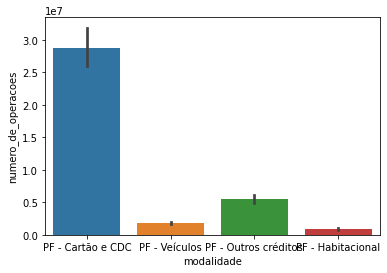

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.barplot(x="modalidade", y="numero_de_operacoes", data=finais)

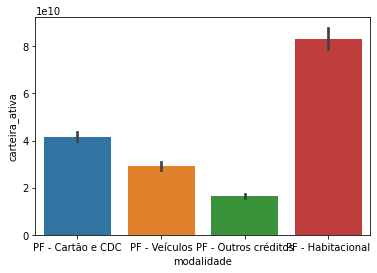

In [87]:
ax = sns.barplot(x="modalidade", y="carteira_ativa", data=finais)

[None, None, None, None, None, None, None, None, None, None, None, None]

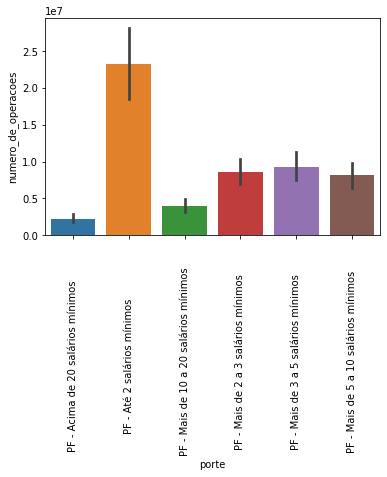

In [97]:
ax = sns.barplot(x="porte", y="numero_de_operacoes", data=finais)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)

[None, None, None, None, None, None, None, None, None, None, None, None]

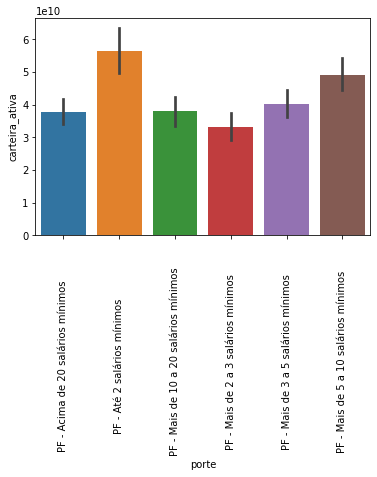

In [98]:
ax = sns.barplot(x="porte", y="carteira_ativa", data=finais)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90)

In [109]:
P = np.array([[0.94, 0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.24, 0.0, 0.76, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.30, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.6, 0.0, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.94, 0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.98, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.993, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.007, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0],
              [0.997, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.003, 0.0],
              [0.999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.001],
              [0.9995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005]])

In [112]:
np.transpose(P)

array([[0.94  , 0.24  , 0.3   , 0.6   , 0.94  , 0.98  , 0.993 , 0.995 ,
        0.995 , 0.995 , 0.997 , 0.999 , 0.9995],
       [0.06  , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.76  , 0.7   , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.4   , 0.    , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.06  , 0.    , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.02  , 0.    , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.007 , 0.    ,
        0.    , 0.    , 0.    , 0.    , 0.    ],
       [0.    , 0.    , 0.    , 

[[8.68058132e-01 5.23569476e-02 3.97539602e-02 2.78839721e-02
  1.12139888e-02 7.19999280e-04 1.29999870e-05 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]]
[[0.93968491 0.06031509 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.2407128  0.         0.7592872  0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.29858631 0.         0.         0.70141369 0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.59783388 0.         0.         0.         0.40216612 0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.93579454 0.         0.         0.         0.         0.06420546
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.98194444 0.         0.         0.         0

<ipython-input-126-e4cb743df60c>:71: RuntimeWarning: invalid value encountered in true_divide
  P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]


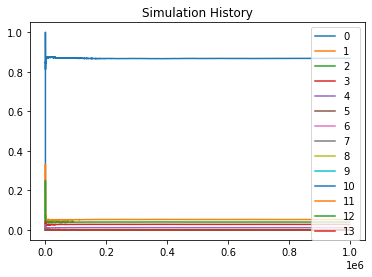

In [126]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt
P = np.array([[0.94, 0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.24, 0.0, 0.76, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.30, 0.0, 0.0, 0.7, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.6, 0.0, 0.0, 0.0, 0.4, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.94, 0.0, 0.0, 0.0, 0.0, 0.06, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.98, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.993, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.007, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0, 0.0, 0.0],
              [0.995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.005, 0.0, 0.0, 0.0],
              [0.997, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.003, 0.0, 0.0],
              [0.999, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.001, 0.0],
              [0.9995, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0005]])

stateChangeHist= np.array([[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])

state=np.array([[1.00, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]])
currentState=0
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[0,0,0,0,0,0,0,0,0,0,0,0,0,0]]

seed(4)

# Simulate from multinomial distribution
def simulate_multinomial(vmultinomial):
    r=np.random.uniform(0.0, 1.0)
    CS=np.cumsum(vmultinomial)
    CS=np.insert(CS,0,0)
    m=(np.where(CS<r))[0]
    nextState=m[len(m)-1]
    return nextState

for x in range(1000000):
    currentRow=np.ma.masked_values((P[currentState]), 0.0)
    nextState=simulate_multinomial(currentRow)
  # Keep track of state changes
    stateChangeHist[currentState,nextState]+=1
  # Keep track of the state vector itself
    state=np.array([[0,0,0,0,0,0,0,0,0,0,0,0,0,0]])
    state[0, nextState]=1.0
  # Keep track of state history
    stateHist=np.append(stateHist,state,axis=0)
    currentState=nextState
  # calculate the actual distribution over the 3 states so far
    totals=np.sum(stateHist,axis=0)
    gt=np.sum(totals)
    distrib=totals/gt
    distrib=np.reshape(distrib,(1, 14))
    distr_hist=np.append(distr_hist,distrib,axis=0)
                       
                       
print(distrib)
P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
# Check estimated state transition probabilities based on history so far:
print(P_hat)
dfDistrHist = pd.DataFrame(distr_hist)
# Plot the distribution as the simulation progresses over time
dfDistrHist.plot(title="Simulation History")
plt.show()

In [125]:
P_hat

array([[0.92874109, 0.07125891, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.15      , 0.        , 0.85      , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.45098039, 0.        , 0.        , 0.54901961, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.39285714, 0.        , 0.        , 0.        , 0.60714286,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [0.88235294, 0.        , 0.        , 0.        , 0.        ,
        0.11764706, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        ],
       [1.        , 0.        , 0. 

[[0.4955045  0.41158841 0.09290709]]
[[0.20362903 0.68346774 0.11290323]
 [0.91019417 0.         0.08980583]
 [0.20652174 0.79347826 0.        ]]


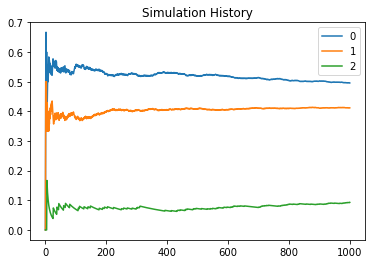

In [118]:
import numpy as np
import pandas as pd
from random import seed
from random import random
import matplotlib.pyplot as plt
P = np.array([[0.2, 0.7, 0.1],
              [0.9, 0.0, 0.1],
              [0.2, 0.8, 0.0]])
stateChangeHist= np.array([[0.0,  0.0,  0.0],
                          [0.0, 0.0,  0.0],
                          [0.0, 0.0,  0.0]])
state=np.array([[1.0, 0.0, 0.0]])
currentState=0
stateHist=state
dfStateHist=pd.DataFrame(state)
distr_hist = [[0,0,0]]
seed(4)
# Simulate from multinomial distribution
def simulate_multinomial(vmultinomial):
    r=np.random.uniform(0.0, 1.0)
    CS=np.cumsum(vmultinomial)
    CS=np.insert(CS,0,0)
    m=(np.where(CS<r))[0]
    nextState=m[len(m)-1]
    return nextState
for x in range(1000):
    currentRow=np.ma.masked_values((P[currentState]), 0.0)
    nextState=simulate_multinomial(currentRow)
  # Keep track of state changes
    stateChangeHist[currentState,nextState]+=1
  # Keep track of the state vector itself
    state=np.array([[0,0,0]])
    state[0,nextState]=1.0
  # Keep track of state history
    stateHist=np.append(stateHist,state,axis=0)
    currentState=nextState
  # calculate the actual distribution over the 3 states so far
    totals=np.sum(stateHist,axis=0)
    gt=np.sum(totals)
    distrib=totals/gt
    distrib=np.reshape(distrib,(1,3))
    distr_hist=np.append(distr_hist,distrib,axis=0)
print(distrib)
P_hat=stateChangeHist/stateChangeHist.sum(axis=1)[:,None]
# Check estimated state transition probabilities based on history so far:
print(P_hat)
dfDistrHist = pd.DataFrame(distr_hist)
# Plot the distribution as the simulation progresses over time
dfDistrHist.plot(title="Simulation History")
plt.show()